In [28]:
import openmc
import numpy as np
import matplotlib.pyplot as plt

In [29]:
"""Creazione uranio """

uo2_central = openmc.Material(1, "uo2_central")

uo2_central.add_nuclide("U235", 0.025)
uo2_central.add_nuclide("U238", 0.975)
uo2_central.add_nuclide("O16", 2)
uo2_central.set_density("g/cm3", 10)        #Densità da riguardare
uo2_central.temperature = 430

uo2_internal = openmc.Material(2, "uo2_internal")

uo2_internal.add_nuclide("U235", 0.035)
uo2_internal.add_nuclide("U238", 0.965)
uo2_internal.add_nuclide("O16", 2)
uo2_internal.set_density("g/cm3", 10)       #Densità da riguardare
uo2_internal.temperature = 430

uo2_external = openmc.Material(3, "uo2_external")

uo2_external.add_nuclide("U235", 0.05)
uo2_external.add_nuclide("U238", 0.95)
uo2_external.add_nuclide("O16", 2)
uo2_external.set_density("g/cm3", 10)       #Densità da riguardare
uo2_external.temperature = 430

uo2_poisoned= openmc.Material(4, "uo2_poisoned")   #da rivedere la parte dei pin con il gadolino

uo2_poisoned.add_nuclide("U235", 0.025)
uo2_poisoned.add_nuclide("U238", 0.975)
uo2_poisoned.add_nuclide("O16", 5)
uo2_poisoned.add_element("Gd", 2)
uo2_poisoned.set_density("g/cm3", 10)       #Densità da riguardare
uo2_poisoned.temperature = 430


"""Creazione Cladding, gape e acqua"""

zirconium = openmc.Material(5,name = "zirconium")
zirconium.add_element("Zr", 1)
zirconium.set_density("g/cm3", 6.5)
zirconium.temperature = 300 

gap = openmc.Material(6,name = "gap")         #parametri modificabile (da chiedere)
gap.add_element("He", 1)
gap.set_density("g/cm3", 1e-6)
gap.temperature = 300

water = openmc.Material(7,name = "water")
water.add_element("H", 2)
water.add_nuclide("O16", 1)
water.set_density("g/cm3", 1)
water.temperature = 300
water.add_s_alpha_beta("c_H_in_H2O")

"""creazione AIC"""
Argento = openmc.Material(8,name = "Argento")
Argento.add_element("Ag", 1)
Argento.set_density("g/cm3", 10.5) 
Argento.temperature = 350                   #DA CHIEDERE

Indio = openmc.Material(9,name = "Indio")
Indio.add_element("In", 1)
Indio.set_density("g/cm3", 7.31) 
Indio.temperature = 350

Cadmio = openmc.Material(10,name = "Cadmio")
Cadmio.add_element("Cd", 1)
Cadmio.set_density("g/cm3", 8.65) 
Cadmio.temperature = 350

AIC = openmc.Material.mix_materials([Argento, Indio, Cadmio], [0.8, 0.15, 0.05], "wo") 

"""creazione acciaio """                    #DA CHIEDERE/RIFARE
Ferro = openmc.Material(11,name = "Ferro")
Ferro.add_element("Fe", 1)
Ferro.set_density("g/cm3", 7.87)
Ferro.temperature = 350

Carbonio = openmc.Material(12,name = "Carbonio")
Carbonio.add_nuclide("C0", 1)
Carbonio.set_density("g/cm3", 2.26)
Carbonio.temperature = 350

Acciaio = openmc.Material.mix_materials([Ferro, Carbonio], [0.98, 0.02], "wo")


"""metodo alternativo per creare acciaio
steel = openmc.Material(name='Stainless Steel')
steel.set_density('g/cm3', 8.00)
steel.add_element('C', 0.08, percent_type='wo')
steel.add_element('Si', 1.00, percent_type='wo')
steel.add_element('Mn', 2.00, percent_type='wo')
steel.add_element('P', 0.045, percent_type='wo')
steel.add_element('S', 0.030, percent_type='wo')
steel.add_element('Cr', 20.0, percent_type='wo')
steel.add_element('Ni', 11.0, percent_type='wo')
steel.add_element('Fe', 65.845, percent_type='wo')
"""


materials = openmc.Materials([uo2_external, uo2_internal, uo2_central, uo2_poisoned, zirconium, gap, water])
materials.export_to_xml()


/openmc_venv/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=1.
  warn(msg, IDWarning)
/openmc_venv/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=2.
  warn(msg, IDWarning)
/openmc_venv/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=3.
  warn(msg, IDWarning)
/openmc_venv/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=4.
  warn(msg, IDWarning)
/openmc_venv/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=5.
  warn(msg, IDWarning)
/openmc_venv/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exists with id=6.
  warn(msg, IDWarning)
/openmc_venv/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Material instance already exist

In [30]:
#geometria
fuel_radius = 0.4095
gap_thickness = 0.0085
cladding_thickness = 0.057
pin_pitch = 1.26
assembly_gap=0.08
num_fuel_rod= 17     #assembly è un 17x17
assembly_lenght= pin_pitch*num_fuel_rod  - assembly_gap  # da togliere il assembly gap



In [31]:
fuel_radius = 0.4095
gap_thickness = 0.0085          #0.4180-0.4095
cladding_thickness = 0.4750-0.4180
pin_pitch = 1.2618
pin_height = 200
num_cells = 17
lattice_length = pin_pitch * num_cells # 21.5313 (assembly pitch) - 2*0.0095 (gap between fuel and clad)


envelope_radius = lattice_length/2 + 20 # raggio che circonda tutto il core

fuel_cyl = openmc.ZCylinder(r=fuel_radius)
gap_cyl = openmc.ZCylinder(r=fuel_radius + gap_thickness)
clad_cyl = openmc.ZCylinder(r=fuel_radius + gap_thickness + cladding_thickness)

pin_upper_surface = openmc.ZPlane(z0=pin_height/2, boundary_type='vacuum')
pin_lower_surface = openmc.ZPlane(z0=-pin_height/2, boundary_type='vacuum')

fuel_region = -fuel_cyl 
gap_region = +fuel_cyl & -gap_cyl
clad_region = +gap_cyl & -clad_cyl
water_region = +clad_cyl 

fuel_cell_internal = openmc.Cell(region=fuel_region, fill=uo2_internal)
fuel_cell_central = openmc.Cell(region=fuel_region, fill=uo2_central)
fuel_cell_external = openmc.Cell(region=fuel_region, fill=uo2_external)
fuel_cell_poisoned = openmc.Cell(region=fuel_region, fill=uo2_poisoned)




gap_cell = openmc.Cell(region=gap_region, fill=gap)
clad_cell = openmc.Cell(region=clad_region, fill=zirconium)
water_cell = openmc.Cell(region=water_region, fill=water)


pin_universe = openmc.Universe(cells=[fuel_cell_central, gap_cell, clad_cell, water_cell])


In [32]:
lattice_length = pin_pitch * num_cells

envelope_radius = lattice_length/2 + 20


fuel_cyl = openmc.ZCylinder(r=fuel_radius)
gap_cyl = openmc.ZCylinder(r=fuel_radius + gap_thickness)
clad_cyl = openmc.ZCylinder(r=fuel_radius + gap_thickness + cladding_thickness)

pin_upper_surface = openmc.ZPlane(z0=pin_height/2,boundary_type='vacuum')
pin_lower_surface = openmc.ZPlane(z0=-pin_height/2,boundary_type='vacuum')

fuel_region = -fuel_cyl 
gap_region = +fuel_cyl & -gap_cyl
clad_region = +gap_cyl & -clad_cyl
water_region = +clad_cyl 
fuel_cell_central = openmc.Cell(region=fuel_region, fill=uo2_central)
gap_cell = openmc.Cell(region=gap_region, fill=gap)
clad_cell = openmc.Cell(region=clad_region, fill=zirconium)
water_cell = openmc.Cell(region=water_region, fill=water)


pin_universe = openmc.Universe(cells=[fuel_cell_central, gap_cell, clad_cell, water_cell])

In [33]:
lattice = openmc.RectLattice() 

lattice.lower_left = (-lattice_length/2, -lattice_length/2)
lattice.pitch = (pin_pitch, pin_pitch)
lattice.outer = openmc.Universe(cells=[openmc.Cell(fill=water)])
lattice.universes = np.tile(pin_universe, (num_cells, num_cells))
# oppure
# lattice.universes = [[pin_universe]*num_cells]*num_cells

outer_cyl = openmc.ZCylinder(r=envelope_radius, boundary_type='vacuum')
# upper_plane = openmc.ZPlane(z0=pin_height/2, boundary_type='vacuum')
# lower_plane = openmc.ZPlane(z0=-pin_height/2, boundary_type='vacuum')   
envelope_region = -outer_cyl & -pin_upper_surface & +pin_lower_surface
envelope_cell = openmc.Cell(region=envelope_region, fill=lattice)
assembly_universe = openmc.Universe(cells=[envelope_cell])

geometry = openmc.Geometry(assembly_universe)
geometry.export_to_xml()

In [34]:
ll,ur = geometry.bounding_box
point = openmc.stats.Box(lower_left=ll, upper_right=ur)
source = openmc.IndependentSource(space=point, constraints={'fissionable': True})  # se da problemi dicendoti che il raggio è troppo piccolo puoi togliere il 'fissionable'=true e aumenta i settings.inactive (=250 per esempio)

settings = openmc.Settings()
settings.source = source
settings.batches = 1000
settings.inactive = 100
settings.particles = 1000
settings.temperature = {"method": "interpolation"}

settings.export_to_xml()

In [35]:
openmc.config["cross_sections"] = "/root/OpenMC/openmc/prova/endfb71/endfb-vii.1-hdf5/cross_sections.xml"
openmc.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

KeyboardInterrupt: 

CREAZIONE DEI VARI UNIVERSE CON TUTTI I PIN E DELLE ASSEMBLY

In [ ]:
#modellazione delle varie fuel rod
#ho considerato i dati geometrici del file PRATIC_core_spec
fuel_radius = 0.4107
gap_thickness = 0.0089         #0.4180-0.4095
cladding_thickness = 0.4757-0.4186
pin_pitch = 1.2618
pin_height = 200
num_cells = 17
lattice_length = pin_pitch * num_cells # 21.5313 (assembly pitch) - 2*0.0095 (gap between fuel and clad)

#empty guided tube
guided_tube_in_radius = 0.5618
guided_tube_out_radius = 0.6029

#instrumentation tube
instrumentation_tube_in_radius = 0.5598
instrumentation_tube_out_radius = 0.6059

env_radius = lattice_length/2 + 20 # raggio che circonda tutto il core

fuel_cyl = openmc.ZCylinder(r=fuel_radius)
gap_cyl = openmc.ZCylinder(r=fuel_radius + gap_thickness)
clad_cyl = openmc.ZCylinder(r=fuel_radius + gap_thickness + cladding_thickness)
guided_in_cyl=openmc.ZCylinder(r=guided_tube_in_radius)
guide_out_cyl=openmc.ZCylinder(r=guided_tube_out_radius)
instrumentation_in_cyl=openmc.ZCylinder(r=instrumentation_tube_in_radius)
instrumentation_out_cyl=openmc.ZCylinder(r=instrumentation_tube_out_radius)

pin_upper_surface = openmc.ZPlane(z0=pin_height/2, boundary_type='vacuum')   #buondary type da rivedere
pin_lower_surface = openmc.ZPlane(z0=-pin_height/2, boundary_type='vacuum')

#regioni del fuel pin
fuel_region = -fuel_cyl 
gap_region = +fuel_cyl & -gap_cyl
clad_region = +gap_cyl & -clad_cyl
water_region = +clad_cyl 

#regioni dei guided tube
water_in_region=-guided_in_cyl
clad_tube_region=+guided_in_cyl & -guide_out_cyl
water_out_region=+guide_out_cyl

#regioni dei instrumentation tube
water_in_instrumentation_region=-instrumentation_in_cyl
clad_tube_instrumentation_region=+instrumentation_in_cyl & -instrumentation_out_cyl
water_out_instrumentation_region=+instrumentation_out_cyl

#celle dei fuel pin
fuel_cell_internal = openmc.Cell(region=fuel_region, fill=uo2_internal)
fuel_cell_central = openmc.Cell(region=fuel_region, fill=uo2_central)
fuel_cell_external = openmc.Cell(region=fuel_region, fill=uo2_external)
fuel_cell_poisoned = openmc.Cell(region=fuel_region, fill=uo2_poisoned)

gap_cell = openmc.Cell(region=gap_region, fill=gap)
clad_cell = openmc.Cell(region=clad_region, fill=zirconium)
water_cell = openmc.Cell(region=water_region, fill=water)

#creazione degli universi dei vari fuel pin
pin_universe_central = openmc.Universe(cells=[fuel_cell_central, gap_cell, clad_cell, water_cell])
pin_universe_internal = openmc.Universe(cells=[fuel_cell_internal, gap_cell, clad_cell, water_cell])
pin_universe_external = openmc.Universe(cells=[fuel_cell_external, gap_cell, clad_cell, water_cell])
pin_universe_poisoned = openmc.Universe(cells=[fuel_cell_poisoned, gap_cell, clad_cell, water_cell])

#celle dei guided tube
water_in_tube_cell=openmc.Cell(region=water_in_region, fill=water)
clad_tube_cell=openmc.Cell(region=clad_tube_region, fill=zirconium)
water_out_tube_cell=openmc.Cell(region=water_out_region, fill=water)

guided_tube_universe=openmc.Universe(cells=[water_in_tube_cell, clad_tube_cell, water_out_tube_cell])

#celle del instrumentation tube
water_in_instrumentation_cell=openmc.Cell(region=water_in_instrumentation_region, fill=water)
clad_tube_instrumentation_cell=openmc.Cell(region=clad_tube_instrumentation_region, fill=zirconium)
water_out_instrumentation_cell=openmc.Cell(region=water_out_instrumentation_region, fill=water) 

instrumentation_tube_universe=openmc.Universe(cells=[water_in_instrumentation_cell, clad_tube_instrumentation_cell, water_out_instrumentation_cell])



In [ ]:
#ora devo definire tutti i vari assembly

#central assembly

#vettori con le coordinate dei "buchi" ovvero le posizioni in cui ci sono i pin avvelenati, i guided tube e gli instrumentation tube
x_poisoned=np.array([3,3,6,6,10,10,13,13])
y_poisoned=np.array([6,10,3,13,3,13,6,10])

#osservazione: i guided tube e il canale per la strumentazionehanno le stesse coordinate in tutti gli assembly quindi si potrebbero anche non ridefinire all'inizio di ogni assembly_universe (io l'ho fatto per completezza)
x_guided_tube=np.array([2,2,2,3,3,5,5,5,5,5,8,8,8,8,11,11,11,11,11,13,13,14,14,14])
y_guided_tube=np.array([5,8,11,3,13,2,5,8,11,14,2,5,11,14,2,5,8,11,14,3,13,5,8,11])

x_instrumentation=np.array([8])
y_instrumentation=np.array([8])

central_lattice=openmc.RectLattice()
central_lattice.lower_left = (-lattice_length/2, -lattice_length/2)
central_lattice.pitch = (pin_pitch, pin_pitch)
central_lattice.universes= [[pin_universe_central]*num_cells]*num_cells
central_lattice.universes[x_poisoned, y_poisoned] = pin_universe_poisoned 
central_lattice.universes[x_guided_tube, y_guided_tube] = guided_tube_universe
central_lattice.universes[x_instrumentation, y_instrumentation] = instrumentation_tube_universe
central_lattice.outer = openmc.Universe(cells=[openmc.Cell(fill=water)])

#versione alternativa con un ciclo for
#for x, y in zip(x_poisoned, y_poisoned):
 #   central_lattice.universes[x][y] = pin_universe_poisoned

#envelop che circonda l'assembly da rivedere, da capire se serve o no
env_cyl_central=openmc.ZCylinder(r=env_radius, boundary_type='vacuum')  ###

upper_surface=openmc.ZPlane(z0=pin_height/2, boundary_type='reflective') #da rivedere se è la stessa per tutti(dovrebbe)+ il tipo di barriera se reflective o no
lower_surface=openmc.ZPlane(z0=-pin_height/2, boundary_type='reflective') #da rivedere se è la stessa per tutti(dovrebbe)+ il tipo di barriera se reflective o no

central_assembly_region= -env_cyl_central & -upper_surface & +lower_surface
central_assembly_cell=openmc.Cell(region=central_assembly_region, fill=central_lattice)

central_assembly_universe=openmc.Universe(cells=[central_assembly_cell])



In [ ]:
#external assembly

#vettori con le coordinate dei "buchi" ovvero le posizioni in cui ci sono i pin avvelenati, i guided tube e gli instrumentation tube

x_poisoned=np.array([1,1,2,2,3,3,4,4,4,6,6,6,6,8,8,10,10,10,10,12,12,12,13,13,14,14,15,15])                             #ma porca puttana ho perso tutta la parte sugli exteranl assembly !!! (rabbia)
y_poisoned=np.array([4,12,2,14,6,10,1,8,15,3,6,10,13,4,12,3,6,10,13,1,8,15,6,10,2,14,4,12])

x_guided_tube=np.array([2,2,2,3,3,5,5,5,5,5,8,8,8,8,11,11,11,11,11,13,13,14,14,14])
y_guided_tube=np.array([5,8,11,3,13,2,5,8,11,14,2,5,11,14,2,5,8,11,14,3,13,5,8,11])

x_instrumentation=np.array([8])
y_instrumentation=np.array([8])

external_lattice=openmc.RectLattice()
external_lattice.lower_left = (-lattice_length/2, -lattice_length/2)
external_lattice.pitch = (pin_pitch, pin_pitch)
external_lattice.universes= [[pin_universe_central]*num_cells]*num_cells  #non dovrebbe dare problemi nel caso modificare gli indici indicando di che tipo di assembly fanno parte quindi da x_poisoned -> x_poisoned_external e così via
external_lattice.universes[x_poisoned, y_poisoned] = pin_universe_poisoned 
external_lattice.universes[x_guided_tube, y_guided_tube] = guided_tube_universe
external_lattice.universes[x_instrumentation, y_instrumentation] = instrumentation_tube_universe
external_lattice.outer = openmc.Universe(cells=[openmc.Cell(fill=water)])

#envelop che circonda l'assembly da rivedere, da capire se serve o no
env_cyl_external=openmc.ZCylinder(r=env_radius, boundary_type='vacuum')

upper_surface=openmc.ZPlane(z0=pin_height/2, boundary_type='reflective') #da rivedere se è la stessa per tutti(dovrebbe)+ il tipo di barriera se reflective o no
lower_surface=openmc.ZPlane(z0=-pin_height/2, boundary_type='reflective') #da rivedere se è la stessa per tutti(dovrebbe)+ il tipo di barriera se reflective o no

external_assembly_region= -env_cyl_external & -upper_surface & +lower_surface
external_assembly_cell=openmc.Cell(region=external_assembly_region, fill=external_lattice)

external_assembly_universe=openmc.Universe(cells=[external_assembly_cell])

In [ ]:
#internal assembly

#vettori con le coordinate dei "buchi" ovvero le posizioni in cui ci sono i pin avvelenati, i guided tube e gli instrumentation tube
x_poisoned=np.array([1,1,1,2,2,3,3,4,4,4,4,4,6,6,6,6,8,8,8,8,10,10,10,10,12,12,12,12,12,13,13,14,14,15,15,15])
y_poisoned=np.array([4,8,12,2,14,6,10,1,4,8,12,15,3,6,10,13,1,4,12,15,3,6,10,13,1,4,8,12,15,6,10,2,14,4,8,12])

x_guided_tube=np.array([2,2,2,3,3,5,5,5,5,5,8,8,8,8,11,11,11,11,11,13,13,14,14,14])
y_guided_tube=np.array([5,8,11,3,13,2,5,8,11,14,2,5,11,14,2,5,8,11,14,3,13,5,8,11])

x_instrumentation=np.array([8])
y_instrumentation=np.array([8])

internal_lattice=openmc.RectLattice()
internal_lattice.lower_left = (-lattice_length/2, -lattice_length/2)
internal_lattice.pitch = (pin_pitch, pin_pitch)
internal_lattice.universes= [[pin_universe_central]*num_cells]*num_cells
internal_lattice.universes[x_poisoned, y_poisoned] = pin_universe_poisoned 
internal_lattice.universes[x_guided_tube, y_guided_tube] = guided_tube_universe
internal_lattice.universes[x_instrumentation, y_instrumentation] = instrumentation_tube_universe
internal_lattice.outer = openmc.Universe(cells=[openmc.Cell(fill=water)])

#versione alternativa con un ciclo for
#for x, y in zip(x_poisoned, y_poisoned):
 #   internal_lattice.universes[x][y] = pin_universe_poisoned

#envelop che circonda l'assembly da rivedere, da capire se serve o no
env_cyl_internal=openmc.ZCylinder(r=env_radius, boundary_type='vacuum')

upper_surface=openmc.ZPlane(z0=pin_height/2, boundary_type='reflective') #da rivedere se è la stessa per tutti(dovrebbe)+ il tipo di barriera se reflective o no
lower_surface=openmc.ZPlane(z0=-pin_height/2, boundary_type='reflective') #da rivedere se è la stessa per tutti(dovrebbe)+ il tipo di barriera se reflective o no

internal_assembly_region= -env_cyl_internal & -upper_surface & +lower_surface
internal_assembly_cell=openmc.Cell(region=internal_assembly_region, fill=internal_lattice)

internal_assembly_universe=openmc.Universe(cells=[internal_assembly_cell])


prova di stampa di un assembly per vedere se tutto ok

In [ ]:
geometry_central_assembly = openmc.Geometry(central_assembly_universe)
geometry_central_assembly.export_to_xml()

In [ ]:
plot_central_assembly = openmc.Plot()
plot_central_assembly.filename = "plot_central_assembly"
plot_central_assembly.basis = 'xy'
plot_central_assembly.origin = (0,0,0)
plot_central_assembly.width = (2*env_radius, 2*env_radius)
plot_central_assembly.pixels = (800, 800)
plot_central_assembly.color_by = 'material'
plot_central_assembly.colors = {uo2_central: "orange", uo2_poisoned:"green",gap: "purple", zirconium: "grey", water: "lightblue"}




plots = openmc.Plots([plot_central_assembly])
plots.export_to_xml()

In [ ]:
openmc.plot_geometry()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

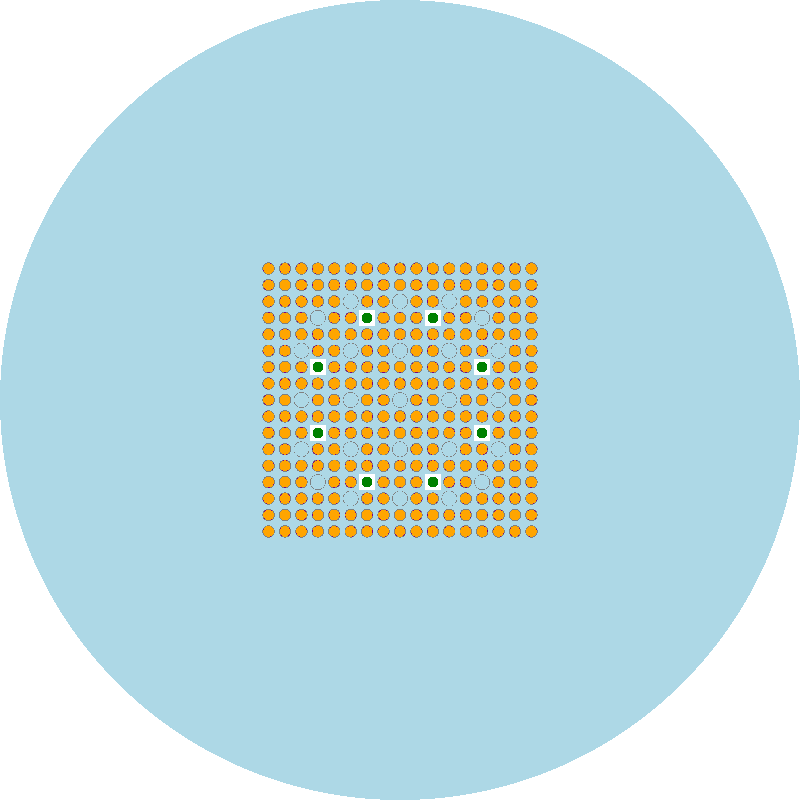

In [ ]:
from IPython.display import Image
Image(filename='plot_central_assembly.png')

In [ ]:
geometry_internal_assembly = openmc.Geometry(internal_assembly_universe)
geometry_internal_assembly.export_to_xml()

In [ ]:
plot_internal_assembly = openmc.Plot()
plot_internal_assembly.filename = "plot_internal_assembly"
plot_internal_assembly.basis = 'xy'
plot_internal_assembly.origin = (0,0,0)
plot_internal_assembly.width = (2*env_radius, 2*env_radius)
plot_internal_assembly.pixels = (800, 800)
plot_internal_assembly.color_by = 'material'
plot_internal_assembly.colors = {uo2_central: "orange", uo2_poisoned:"green",gap: "purple", zirconium: "grey", water: "lightblue"}

plots_internal_assembly = openmc.Plots([plot_internal_assembly])
plots_internal_assembly.export_to_xml()

In [ ]:
openmc.plot_geometry()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

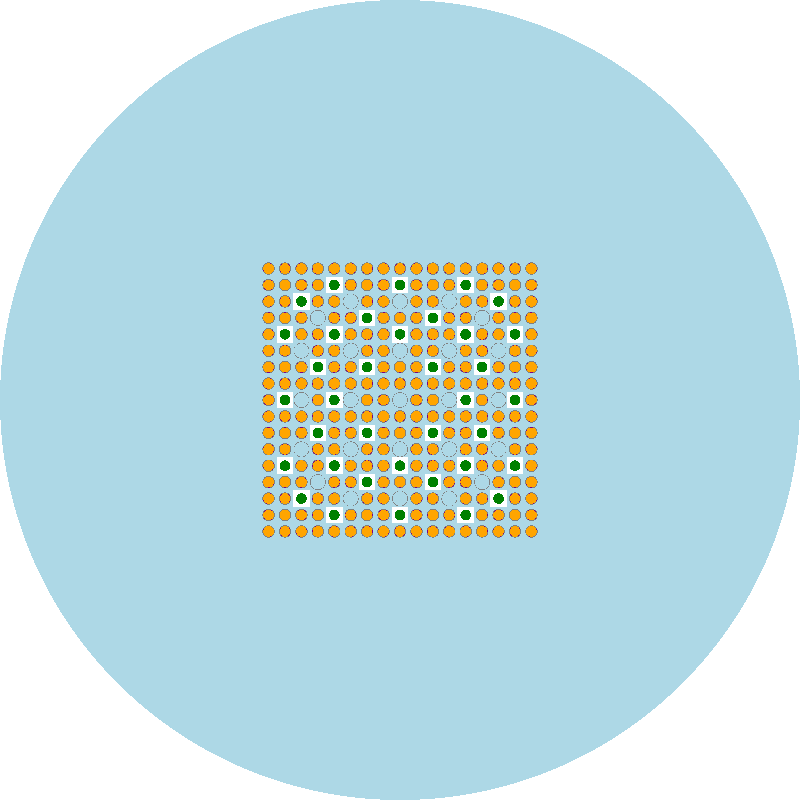

In [ ]:
from IPython.display import Image
Image(filename='plot_internal_assembly.png')

In [ ]:
geometry_external_assembly = openmc.Geometry(external_assembly_universe)
geometry_external_assembly.export_to_xml()

In [ ]:
plot_external_assembly = openmc.Plot()
plot_external_assembly.filename = "plot_external_assembly"
plot_external_assembly.basis = 'xy'
plot_external_assembly.origin = (0,0,0)
plot_external_assembly.width = (2*env_radius, 2*env_radius)
plot_external_assembly.pixels = (1000, 1000)
plot_external_assembly.color_by = 'material'
plot_external_assembly.colors = {uo2_central: "orange", uo2_poisoned:"green",gap: "purple", zirconium: "grey", water: "lightblue"}

plots_external_assembly = openmc.Plots([plot_external_assembly])
plots_external_assembly.export_to_xml()

In [ ]:
openmc.plot_geometry() 

# da capire perchè nelle barre con il gadolino ho un contorno bianco, quasi come se sono ci fosse l'acqua o bo?
# e anche come raggruppare tutti i vari plot in un unico file per evitare di fare tutto sto bordello

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

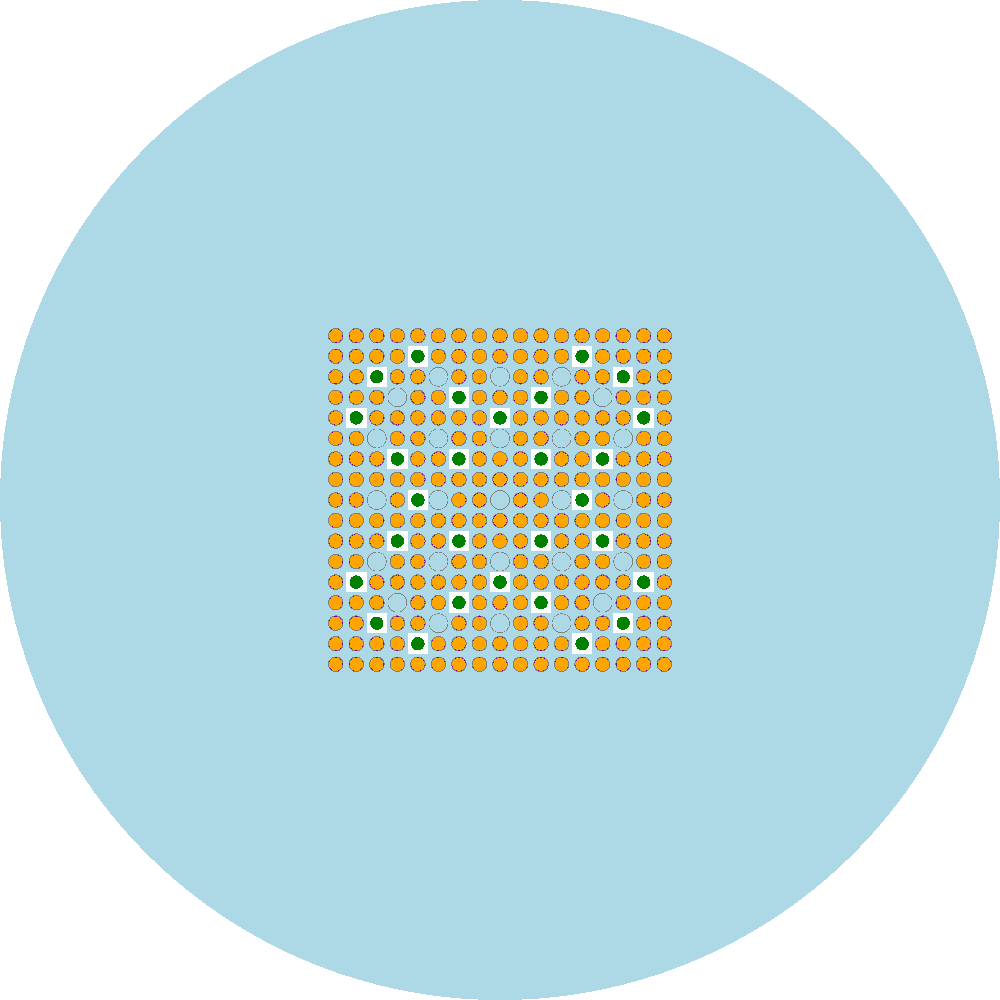

In [ ]:
from IPython.display import Image
Image(filename='plot_external_assembly.png')

In [ ]:
#mie sperimentazioni con le matrici (scusate ma sono proprio un babbo in ste robe)

"""#Q=np.array([[1,2,3,4],[5,6,7,8],[9,10,11,12],[13,14,15,16]])
Q=np.arange(1,17).reshape(4,4)
print(Q)

Q[1,1]=0
print(Q)

x=np.array([1,1,1,1])
Q[1,:]=x
print(Q)

Q[x,:]=0
print(Q)

y=np.array([1, 3])
z=np.array([1, 3])
Q[y,z]=0
print(Q)

#Q[[1,2]]=0
#print(Q)

#Q[y,y]=0
#print(Q)


A = np.arange(1, 17).reshape(4, 4)

righe = np.array([1, 2])   # indici delle righe
colonne = np.array([1, 3]) # indici delle colonne

A[righe, righe] = 0

print(A)"""

'#Q=np.array([[1,2,3,4],[5,6,7,8],[9,10,11,12],[13,14,15,16]])\nQ=np.arange(1,17).reshape(4,4)\nprint(Q)\n\nQ[1,1]=0\nprint(Q)\n\nx=np.array([1,1,1,1])\nQ[1,:]=x\nprint(Q)\n\nQ[x,:]=0\nprint(Q)\n\ny=np.array([1, 3])\nz=np.array([1, 3])\nQ[y,z]=0\nprint(Q)\n\n#Q[[1,2]]=0\n#print(Q)\n\n#Q[y,y]=0\n#print(Q)\n\n\nA = np.arange(1, 17).reshape(4, 4)\n\nrighe = np.array([1, 2])   # indici delle righe\ncolonne = np.array([1, 3]) # indici delle colonne\n\nA[righe, righe] = 0\n\nprint(A)'

PROSSIMO PASSO: UNIRE TUTTI I VARI ASSEMBLY PER CREARE IL CORE VERO E PROPRIO E RUNNARE LA SIMULAZIONE + VOLENDO PRIMA SI POTREBBE FARE UNA SIMULAZIONE CONSIDERANDO SOLO UN ASSEMBLY con i VARI TIPi.